In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
! pip install seasborn

ERROR: Could not find a version that satisfies the requirement seasborn (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for seasborn


In [14]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/glade/u/home/marchakitus/AIFS_ENS/lib/python3.11/site-packages/seaborn'
Check the permissions.


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [12]:
!hostname

derecho5


In [10]:

# load gencast results
var  = "2m_temperature.nc"
gencast_file = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/gencast_results_2019_2024/gencast_2019_2024_crps_ssr_{}".format(var)
ngcm_file = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/ngcm_results_2019_2024/ngcm_2019_2024_crps_ssr_{}".format(var)
our_file = "/glade/campaign/univ/uchi0018/bing/ours_prediction100/S2S_ens_eval_{}".format(var)
#our_file = "/glade/campaign/univ/uchi0018/bing/predictions_tendency_results/S2S_ens_eval_{}".format(var)
our_file2 = "/glade/campaign/univ/uchi0018/bing/predictions_tendency_results2/S2S_ens_eval_{}".format(var)
amip_file = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/amip_results_2019_2022/amip_2019_crps_ssr_{}".format(var)
#our_file2 = "/glade/campaign/univ/uchi0018/bing/predictions_roll_out_step2_results/S2S_ens_eval_{}".format(var)
#our_file3 = "/glade/campaign/univ/uchi0018/bing/predictions_roll_out_step3_results/S2S_ens_eval_{}".format(var)
#our_file3 = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/ours_prediction100/S2S_ens_eval_{}".format(var)

In [4]:

gencast_file = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/gencast_results_2019_2024/gencast_2019_2024_crps_ssr_{}".format(var)
# amip_file = "/glade/work/bgong/benchmark-dev/crps_by_time.nc"

In [11]:
import xarray as xr
gcast = xr.open_dataset(gencast_file,decode_cf=False)
# ngcm = xr.open_dataset(ngcm_file,decode_cf=False)
ours = xr.open_dataset(our_file,decode_cf=False)
ours2 = xr.open_dataset(our_file2,decode_cf=False)
amip = xr.open_dataset(amip_file,decode_cf=False)

In [13]:
amip["crps"]

<xarray.DataArray 'crps' (prediction_timedelta: 46)> Size: 184B
[46 values with dtype=float32]
Coordinates:
  * prediction_timedelta  (prediction_timedelta) int64 368B 0 24 ... 1056 1080
Attributes:
    _FillValue:  nan

In [14]:
ours["crps"].values

array([0.        , 0.68640526, 0.88723343, 1.04994083, 1.20574955,
       1.33666316, 1.43476163, 1.50541977, 1.53476906, 1.54068993,
       1.54371197, 1.55118297, 1.56402167, 1.57189926, 1.5621444 ,
       1.56067922, 1.5591075 , 1.55974887, 1.56712707, 1.575075  ,
       1.57041934, 1.56806186, 1.57087937, 1.5664135 , 1.5628276 ,
       1.56608384, 1.57209627, 1.56466937, 1.56345724, 1.57147289,
       1.56931272, 1.56582623, 1.57182465, 1.58106261, 1.57672744,
       1.57956518, 1.58240995, 1.57799207, 1.58408321, 1.59333816,
       1.59804109, 1.5905839 , 1.59204962, 1.59608291, 1.58825507,
       1.59029598])

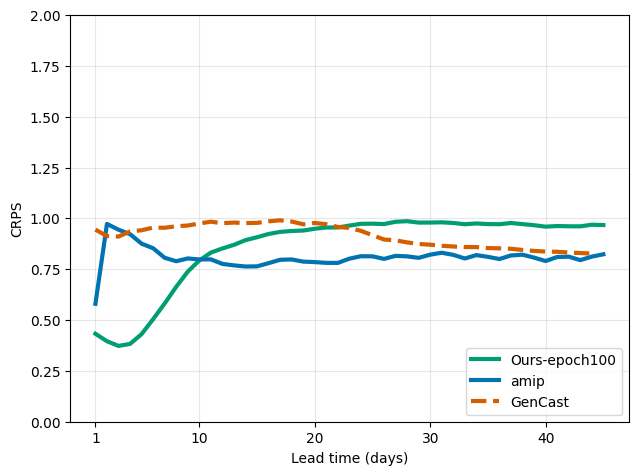

In [17]:

hrss = list(range(0, 46, 1))
locations = [0, 9, 19, 29, 39 ]
labels = [hrss[i+1] for i in locations]
leadtime = list(range(len(hrss)-1))
colors = sns.color_palette("colorblind", 5)
# leadtime = list(range(45))
plt.figure()
plt.plot(leadtime, ours["ssr"].values[1:46], color=colors[2], lw=3, linestyle="-" ,label="Ours-epoch100")
plt.plot(leadtime, amip["ssr"].values[1:46], color=colors[0], lw=3, linestyle="-" ,label="amip")
plt.plot(leadtime[:-1], gcast["ssr"].values[1::2][:44], color=colors[3], lw=3, linestyle="--",label="GenCast")
#plt.plot(leadtime[:-1], ngcm["crps"].values[1::2][:44], color=colors[4], lw=3, linestyle=":",label="NCGM")
plt.xticks(locations, labels)
plt.legend(loc='lower right')
plt.xlabel("Lead time (days)")
plt.ylabel("CRPS")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.ylim(0, 2)
plt.savefig("z500_crps.png", dpi=300)

In [14]:
file = "/glade/campaign/univ/uchi0018/bing/prediction_vae/pangu_plasim_12_24h_10step_2019061700_ens_18.nc"

In [15]:
dt = xr.open_dataset(file, decode_cf=False)

In [16]:

# Check the variables in the dataset
print(dt.data_vars)

Data variables:
    2m_temperature                         (time, latitude, longitude) float32 3MB ...
    10m_u_component_of_wind                (time, latitude, longitude) float32 3MB ...
    10m_v_component_of_wind                (time, latitude, longitude) float32 3MB ...
    mean_sea_level_pressure                (time, latitude, longitude) float32 3MB ...
    surface_pressure                       (time, latitude, longitude) float32 3MB ...
    volumetric_soil_water_layer_1          (time, latitude, longitude) float32 3MB ...
    soil_temperature_level_1               (time, latitude, longitude) float32 3MB ...
    skin_temperature                       (time, latitude, longitude) float32 3MB ...
    sea_surface_temperature                (time, latitude, longitude) float32 3MB ...
    temperature                            (time, level, latitude, longitude) float32 48MB ...
    u_component_of_wind                    (time, level, latitude, longitude) float32 48MB ...
    v_compo

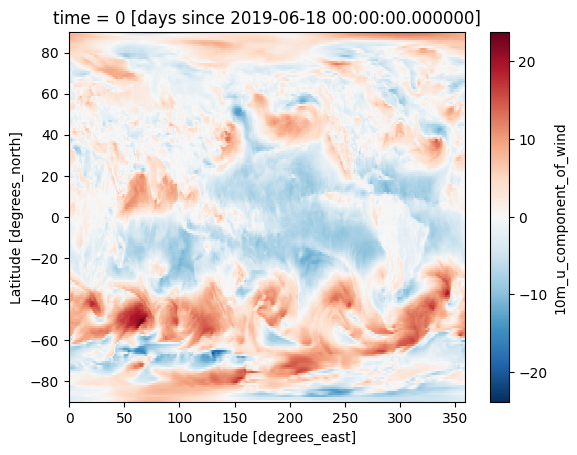

In [25]:
dt["10m_u_component_of_wind"].isel(time=0).plot()

In [ ]:
# Select the first timestamp
t2m_first = dt["2m_temperature"].isel(time=0)
t2m_first